# UAS PEMBELAJARAN MESIN 
### Nama : Hafizh Hilman Asyhari
### NIM : 202331206
### Kelas : D
### Mata Kuliah : Pembelajaran Mesin 
### Program Studi : S1 Teknik Informatika 
### Fakultas : Fakultas Telematika Energi
#### 2024-2025

## PREPROCESSING DATA

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [11]:
# Load Dataset Anime
anime_df = pd.read_csv('anime.csv')

In [13]:
# Tampilkan nama-nama kolom yang ada di dataset
print(anime_df.columns)

Index(['Title', 'Score', 'Vote', 'Ranked', 'Popularity', 'Episodes', 'Status',
       'Aired', 'Premiered', 'Producers', 'Licensors', 'Studios', 'Source',
       'Duration', 'Rating'],
      dtype='object')


Dataset anime_df memiliki 15 kolom, yang terdiri dari:

- Title: Nama atau judul anime.
- Score: Skor atau penilaian rata-rata yang diberikan untuk anime.
- Vote: Jumlah suara atau vote yang diterima anime.
- Ranked: Peringkat anime berdasarkan skor atau popularitas.
- Popularity: Tingkat popularitas anime.
- Episodes: Jumlah episode dalam anime.
- Status: Status anime (misalnya, apakah sedang tayang, selesai, atau belum mulai).
- Aired: Rentang waktu anime ditayangkan.
- Premiered: Waktu pemutaran perdana anime.
- Producers: Pihak yang memproduksi anime.
- Licensors: Pihak yang memiliki lisensi untuk mendistribusikan anime.
- Studios: Studio yang mengerjakan anime.
- Source: Sumber dari anime (misalnya, manga, novel, game, dll.).
- Duration: Durasi setiap episode anime.
- Rating: Kategori rating atau klasifikasi usia untuk anime (misalnya, R, PG-13, dll.).

In [21]:
# Pilih kolom yang relevan untuk clustering
anime_data = anime_df[['Score', 'Vote', 'Popularity']].dropna()

memilih tiga kolom yang relevan untuk analisis clustering atau pengelompokan, 
yaitu 'Score', 'Vote', dan 'Popularity', dari dataset anime_df

### NORMALISASI Data

In [59]:
from sklearn.preprocessing import StandardScaler

# Normalisasi Data
scaler = StandardScaler()
anime_data_scaled = scaler.fit_transform(anime_data)

# Tampilkan data yang sudah dinormalisasi
print(anime_data_scaled[:5])  # Menampilkan 5 data pertama

[[ 3.84219625  0.21657439 -1.10406926  0.7086881 ]
 [ 3.7303606   9.96796367 -1.26746659  2.48351429]
 [ 3.68562635  6.44449162 -1.264231    2.48351429]
 [ 3.66325922  0.80434174 -1.15939786  0.7086881 ]
 [ 3.64089209  7.29168226 -1.26164252  2.48351429]]


In [61]:
# Inisialisasi Model K-Means dengan n_init dan n_clusters yang baru
kmModelFix = KMeans(n_clusters=5, n_init=10, random_state=42)

### PEMBENTUKAN MODEL

In [38]:
from sklearn.cluster import KMeans
# Tentukan jumlah cluster
kmeans = KMeans(n_clusters=3, random_state=42)

- Pelatihan Model K-Means
- Tentukan jumlah cluster

In [65]:
# Latih model K-Means
kmeans.fit(anime_data_scaled)

# Tampilkan hasil centroid
print("Centroid K-Means:")
print(kmeans.cluster_centers_)

# Tampilkan hasil klasterisasi
anime_data['Cluster'] = kmeans.labels_
print(anime_data.head())

Centroid K-Means:
[[-0.93844077 -0.35241533  0.06096472 -1.06613809]
 [ 1.9679299   0.38939772 -0.96197964  0.7086881 ]
 [ 1.51515461  3.15500627 -1.22830246  2.48351429]
 [-0.29181456 -0.4049761   0.78581293 -1.06613809]
 [ 0.18618365 -0.22207741 -0.44944081  0.7086881 ]
 [ 2.17525657  7.5823657  -1.26188945  2.48351429]
 [-0.82565824 -0.42065328  1.93512545 -1.06613809]
 [ 0.28558488  0.92014105 -1.10911942  0.7086881 ]
 [ 1.05505846 -0.2739526  -0.22165854  0.7086881 ]
 [-0.6044766  -0.01648357 -0.75024605  0.7086881 ]]
   Score     Vote  Popularity  Cluster
0   9.14   128768         508        1
1   9.09  2080863           3        5
2   9.07  1375512          13        5
3   9.06   246431         337        1
4   9.05  1545108          21        5


In [67]:
# Latih model K-Means
kmModelFix.fit(anime_data_scaled)

# Hasil prediksi
hasil_prediksi = kmModelFix.predict(anime_data_scaled)

# Tampilkan hasil prediksi
anime_data['Cluster'] = hasil_prediksi
print(anime_data.head())
# Tampilkan hasil prediksi
anime_data['Cluster'] = hasil_prediksi
print(anime_data.head())

   Score     Vote  Popularity  Cluster
0   9.14   128768         508        3
1   9.09  2080863           3        2
2   9.07  1375512          13        2
3   9.06   246431         337        3
4   9.05  1545108          21        2
   Score     Vote  Popularity  Cluster
0   9.14   128768         508        3
1   9.09  2080863           3        2
2   9.07  1375512          13        2
3   9.06   246431         337        3
4   9.05  1545108          21        2


## Evaluasi Model: Elbow Method

In [45]:
import matplotlib.pyplot as plt

# Hitung inertia untuk berbagai jumlah cluster
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(anime_data_scaled)
    inertia.append(kmeans.inertia_)

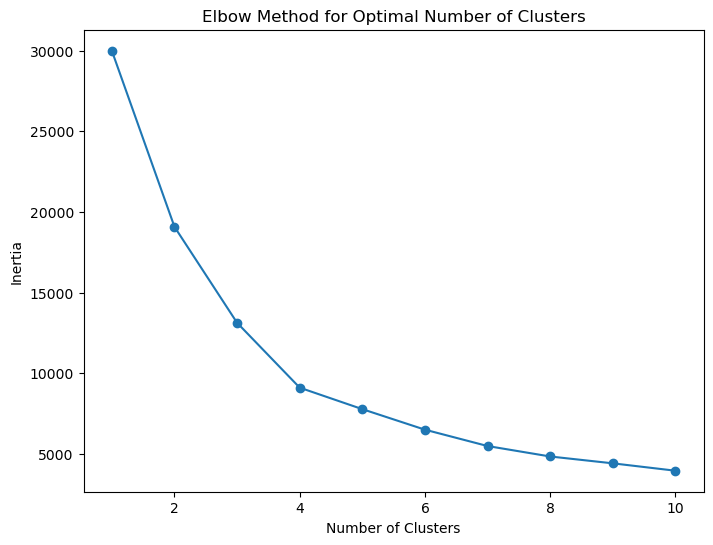

In [48]:
# Plot Elbow Curve
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

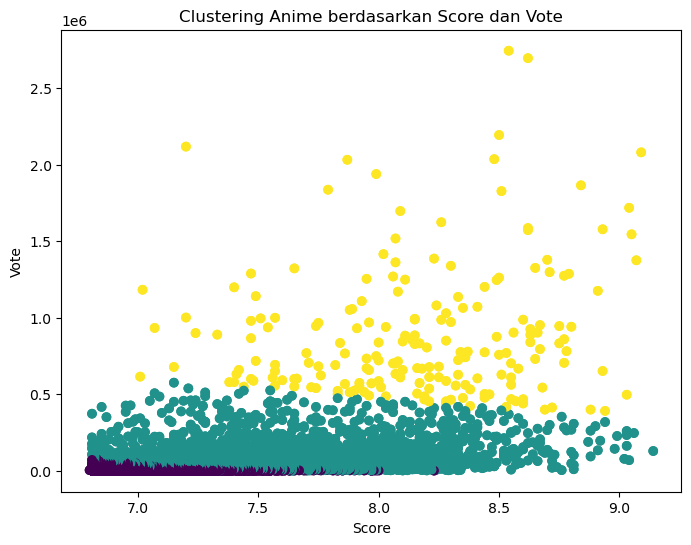

In [54]:
plt.figure(figsize=(8, 6))
plt.scatter(anime_data['Score'], anime_data['Vote'], c=anime_data['Cluster'], cmap='viridis')
plt.title('Clustering Anime berdasarkan Score dan Vote')
plt.xlabel('Score')
plt.ylabel('Vote')
plt.show()